In [23]:
!pip install wfdb numpy scipy matplotlib -q

Loaded: fs=360 Hz, samples=650000, duration=30.1 min
Total beats detected: 2273
Peaks in first 10 sec: 13
First RR interval: 0.814 sec
First HR value: 73.7 bpm


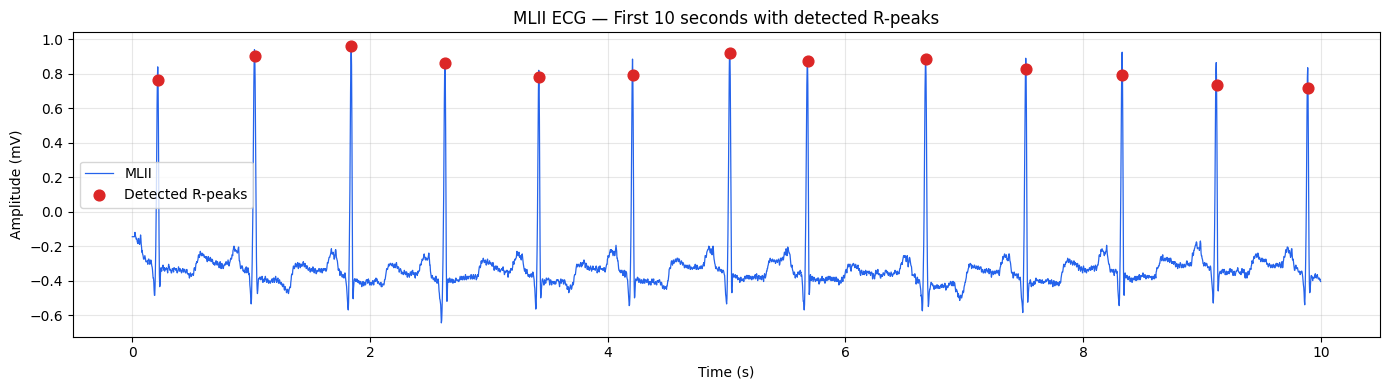

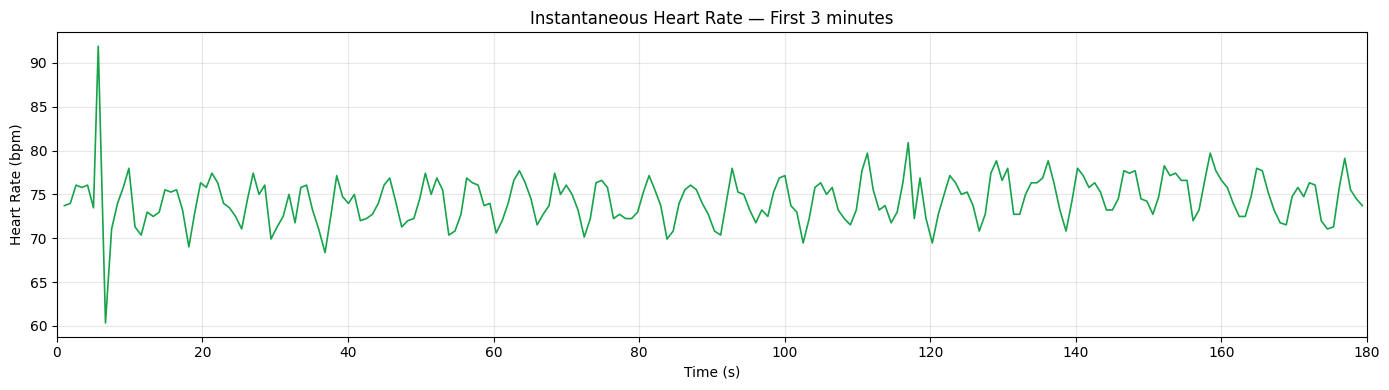

Mean HR: 75.8 bpm
HR range: 52.9 – 115.5 bpm


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks
import wfdb

# Load record
record = wfdb.rdrecord("/content/100")
fs     = record.fs
signal = record.p_signal[:, 0]  # MLII channel only
t      = np.arange(len(signal)) / fs
print(f"Loaded: fs={fs} Hz, samples={len(signal)}, duration={len(signal)/fs/60:.1f} min")

# Bandpass filter 5-15 Hz
def bandpass(sig, lowcut=5.0, highcut=15.0, fs=360, order=4):
    nyq  = fs / 2.0
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype="band")
    return filtfilt(b, a, sig)

filtered = bandpass(signal, fs=fs)

# Derivative -> squaring -> moving window integration
diff    = np.diff(filtered, prepend=filtered[0])
squared = diff ** 2
win_len = int(0.150 * fs)
window  = np.ones(win_len) / win_len
mwi     = np.convolve(squared, window, mode="same")

# R-peak detection
threshold    = 0.08 * np.max(mwi)
min_distance = int(0.250 * fs)
r_peaks, _   = find_peaks(mwi, height=threshold, distance=min_distance)

print(f"Total beats detected: {len(r_peaks)}")
print(f"Peaks in first 10 sec: {np.sum(r_peaks < 10 * fs)}")

# Instantaneous heart rate
rr_intervals = np.diff(r_peaks) / fs
heart_rate   = 60.0 / rr_intervals
hr_times     = t[r_peaks[1:]]
print(f"First RR interval: {rr_intervals[0]:.3f} sec")
print(f"First HR value: {heart_rate[0]:.1f} bpm")

# Plot 1 — first 10 seconds with R-peaks
t10    = int(10 * fs)
mask10 = r_peaks[r_peaks < t10]
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(t[:t10], signal[:t10], color="#2563EB", linewidth=0.9, label="MLII")
ax.scatter(t[mask10], signal[mask10], color="#DC2626", s=60, zorder=5, label="Detected R-peaks")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude (mV)")
ax.set_title("MLII ECG — First 10 seconds with detected R-peaks")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2 — instantaneous heart rate over first 3 minutes
mask3 = hr_times <= 180
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(hr_times[mask3], heart_rate[mask3], color="#16A34A", linewidth=1.2)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Heart Rate (bpm)")
ax.set_title("Instantaneous Heart Rate — First 3 minutes")
ax.set_xlim(0, 180)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mean HR: {heart_rate.mean():.1f} bpm")
print(f"HR range: {heart_rate.min():.1f} – {heart_rate.max():.1f} bpm")